In [ ]:
import json
import pandas as pd
from pathlib import Path
import math
import numpy as np

In [ ]:
import json
import pandas as pd
from pathlib import Path

corner_rows = []
goal_rows = []

# Loop through JSON event files
for file in Path("events").glob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    match_id = file.stem.split("_")[0]

    # Build lookup: id → event (helps find related_events)
    id_lookup = {ev.get("id"): ev for ev in data if ev.get("id")}

    # Collect all goal times in match (for success calculation)
    goals_in_match = []
    for ev in data:
        if ev.get("type", {}).get("name") == "Shot":
            shot = ev.get("shot", {})
            if shot.get("outcome", {}).get("name") == "Goal":
                m = ev.get("minute")
                s = ev.get("second")
                if m is not None and s is not None:
                    goals_in_match.append(m * 60 + s)
                    goal_rows.append({
                        "match_id": match_id,
                        "player": ev.get("player", {}).get("name"),
                        "team": ev.get("team", {}).get("name"),
                        "minute": m,
                        "second": s,
                        "time_sec": m * 60 + s
                    })

    # Process corner kicks
    for i, event in enumerate(data):
        if event.get("pass", {}).get("type", {}).get("name") != "Corner":
            continue

        m = event.get("minute")
        s = event.get("second")
        if m is None or s is None:
            continue
        time_sec = m * 60 + s

        player = event.get("player", {}).get("name")
        team = event.get("team", {}).get("name")
        x, y = event.get("location", [None, None])
        end_x, end_y = event.get("pass", {}).get("end_location", [None, None])
        taker_body_part = event.get("pass", {}).get("body_part", {}).get("name")
        angle = event.get("pass", {}).get("angle")

        # Swing direction
        if x is not None and taker_body_part in ("Right Foot", "Left Foot"):
            left_side = x < 60  # StatsBomb pitch midpoint
            swing_type = "inswinging" if (
                (taker_body_part == "Right Foot" and left_side) or
                (taker_body_part == "Left Foot" and not left_side)
            ) else "outswinging"
        else:
            swing_type = None

        # Success rule (original: goal within 15 seconds of corner)
        success = any(0 <= gt - time_sec <= 10 for gt in goals_in_match)

        # ------------------------------------
        # Improved recipient body-part detection
        # ------------------------------------
        recipient = None
        recipient_bp_full = None

        # helper: check event for bp/player, returns (found_bool, player_name, bp_name)
        def check_event_for_bp(ev):
            # 1) shot body part
            bp = ev.get("shot", {}).get("body_part", {}).get("name")
            if bp:
                return True, ev.get("player", {}).get("name"), bp
            # 2) pass body part
            bp = ev.get("pass", {}).get("body_part", {}).get("name")
            if bp:
                return True, ev.get("player", {}).get("name"), bp
            # 3) carry body part (rare)
            bp = ev.get("carry", {}).get("body_part", {}).get("name")
            if bp:
                return True, ev.get("player", {}).get("name"), bp
            # 4) type name may indicate header
            tname = ev.get("type", {}).get("name", "")
            if isinstance(tname, str) and ("head" in tname.lower() or "header" in tname.lower()):
                return True, ev.get("player", {}).get("name"), "Head"
            return False, None, None

        # 1) Check related events first (most reliable)
        for rid in event.get("related_events", []) or []:
            rel = id_lookup.get(rid)
            if not rel:
                continue
            found, pname, bp = check_event_for_bp(rel)
            if found:
                recipient = pname or recipient
                recipient_bp_full = bp
                break

        # 2) Scan next few events in same possession (small window) if not found
        if recipient_bp_full is None:
            pos_id = event.get("possession")
            # limit to next 40 events or stop when possession changes or time delta > 8s
            for nxt in data[i+1:i+1+40]:
                if nxt.get("possession") != pos_id:
                    break
                nm, ns = nxt.get("minute"), nxt.get("second")
                if nm is None or ns is None:
                    continue
                if (nm * 60 + ns) - time_sec > 8:
                    break
                found, pname, bp = check_event_for_bp(nxt)
                if found:
                    recipient = pname or recipient
                    recipient_bp_full = bp
                    break

        # 3) Final fallback: first Shot in same possession within 15s -> use its shot.body_part
        if recipient_bp_full is None:
            pos_id = event.get("possession")
            for nxt in data[i+1:]:
                if nxt.get("possession") != pos_id:
                    break
                nm, ns = nxt.get("minute"), nxt.get("second")
                if nm is None or ns is None:
                    continue
                if (nm * 60 + ns) - time_sec > 15:
                    break
                if nxt.get("type", {}).get("name") == "Shot":
                    bp = nxt.get("shot", {}).get("body_part", {}).get("name")
                    if bp:
                        recipient = nxt.get("player", {}).get("name") or recipient
                        recipient_bp_full = bp
                    break

        # Normalize to Head / Other / Unknown
        if recipient_bp_full is None:
            recipient_bp_simple = "Unknown"
        elif isinstance(recipient_bp_full, str) and recipient_bp_full.lower() == "head":
            recipient_bp_simple = "Head"
        else:
            recipient_bp_simple = "Other"

        # Store row
        corner_rows.append({
            "match_id": match_id,
            "player": player,
            "team": team,
            "minute": m,
            "second": s,
            "time_sec": time_sec,
            "x": x,
            "y": y,
            "end_x": end_x,
            "end_y": end_y,
            "angle": angle,
            "swing_type": swing_type,
            "recipient_body_part": recipient_bp_simple,
            "success": success
        })

# Convert to DataFrames
df_corners = pd.DataFrame(corner_rows).drop_duplicates(subset=["match_id", "time_sec"])
df_goals = pd.DataFrame(goal_rows).drop_duplicates(subset=["match_id", "time_sec"])

# Save
df_corners.to_csv("corner_deliveries.csv", index=False)
df_goals.to_csv("goals.csv", index=False)


print("Total corners:", len(df_corners))
print("Success rate:", df_corners['success'].mean())
print("Recipient body part counts:")
print(df_corners['recipient_body_part'].value_counts(dropna=False))


Total corners: 34046
Success rate: 0.028960817717206135
Recipient body part counts:
recipient_body_part
Other      16837
Unknown    10369
Head        6840
Name: count, dtype: int64


In [ ]:
df_goals.shape
df_corners.head()


,match_id,player,team,minute,second,time_sec,x,y,end_x,end_y,angle,swing_type,recipient_body_part,success
0,3764237,Lucy Whipp,Birmingham City WFC,6,3,363,120.0,0.1,110.5,50.6,1.756742,outswinging,Head,False
1,3764237,Leah Galton,Manchester United,8,8,488,120.0,80.0,117.0,39.3,-1.644373,inswinging,Unknown,False
2,3764237,Katie Zelem,Manchester United,9,44,584,120.0,0.1,113.7,44.6,1.711435,outswinging,Unknown,False
3,3764237,Katie Zelem,Manchester United,28,49,1729,120.0,0.1,111.4,42.6,1.770453,outswinging,Head,False
4,3764237,Leah Galton,Manchester United,63,47,3827,120.0,80.0,109.1,3.9,-1.713061,inswinging,Other,False


In [ ]:
df_corners.shape

(34046, 14)

In [ ]:
print(df_corners["success"].mean())

0.028960817717206135


Corner kick baseline success rate (goal) is 3.24%, checks out with generally accepted statistics.

In [ ]:
df_corners.groupby("swing_type")["success"].count()

swing_type
inswinging     11559
outswinging    22487
Name: success, dtype: int64

In [ ]:
df_corners.groupby("swing_type")["success"].mean()

swing_type
inswinging     0.030020
outswinging    0.028416
Name: success, dtype: float64

Seems like inswinging/outswinging has no real impact on success rate, but let's run a chi squared test to be sure.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df_corners['swing_type'], df_corners['success'])

chi2, p, dof, expected = chi2_contingency(table)
print(p)


0.4229292653918181


Because the p-value is much above the critical value of 0.05, we can conclude that swing type alone does not impact success rates of corners. Let's see if the position of the delivery has an impact next.

In [ ]:
def corner_zone(row):
    if pd.isna(row['end_x']) or pd.isna(row['end_y']):
        return 'Unknown'
    if 102 <= row['end_x'] <= 120 and 18 <= row['end_y'] <= 62:
        return 'In Box'
    else:
        return 'Out of Box'

df_corners['zone'] = df_corners.apply(corner_zone, axis=1)


In [ ]:
zone_summary = df_corners.groupby('zone')['success'].agg(['count','sum'])
zone_summary['success_rate'] = zone_summary['sum'] / zone_summary['count']
print(zone_summary)


            count  sum  success_rate
zone                                
In Box      27215  868      0.031894
Out of Box   6831  118      0.017274


Let's do another chi-squared test for success rates for corner kick deliveries in the box vs outside of the box.

In [ ]:
table = pd.crosstab(df_corners['zone'], df_corners['success'])

chi2, p, dof, expected = chi2_contingency(table)
print(p)


1.5347170548078558e-10


The chi-squared test for corners inside and outside the box shows there is a statistically significant p value of much below 0.05, so corner kicks inside the box with a success rate of 3.5% are conclusively much better than ones outside the box with a success rate of 2.1%.

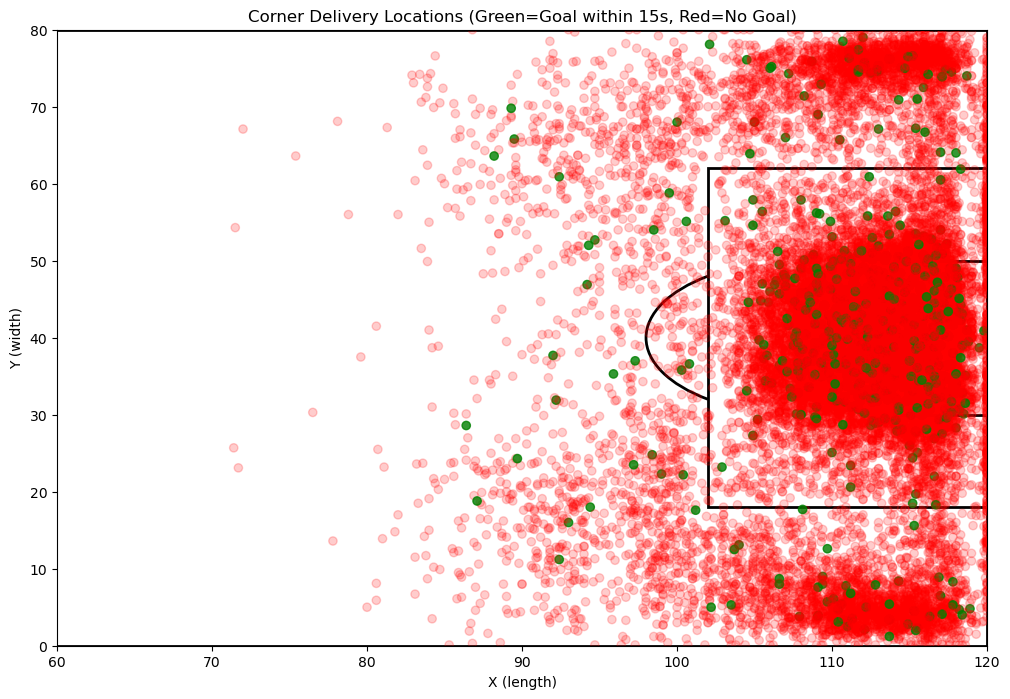

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc

fig, ax = plt.subplots(figsize=(12, 8))

ax.add_patch(Rectangle((0, 0), 120, 80, linewidth=2, edgecolor='black', facecolor='none'))
ax.add_patch(Rectangle((102, 18), 18, 44, linewidth=2, edgecolor='black', facecolor='none'))
ax.add_patch(Arc((108, 40), 20, 20, theta1=127, theta2=233, linewidth=2, edgecolor='black'))
ax.add_patch(Rectangle((114, 30), 6, 20, linewidth=2, edgecolor='black', facecolor='none'))

alphas = df_corners['success'].map({True: 0.8,
                                    False: 0.2})

colors = df_corners['success'].map({True: 'green', False: 'red'})

ax.scatter(df_corners['end_x'], df_corners['end_y'], 
           c=colors, alpha=alphas)

ax.set_xlim(60, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('Corner Delivery Locations (Green=Goal within 15s, Red=No Goal)')
plt.show()


To make it so that we can accurately model, I am going to flip the Y values of the positions for corner kicks on the bottom of the model (120, 0). I will start with the plot I had above.

In [ ]:
bottom_mask = df_corners['y'] < 40  # corners taken from bottom side

df_corners.loc[bottom_mask, 'end_y'] = 80 - df_corners.loc[bottom_mask, 'end_y']

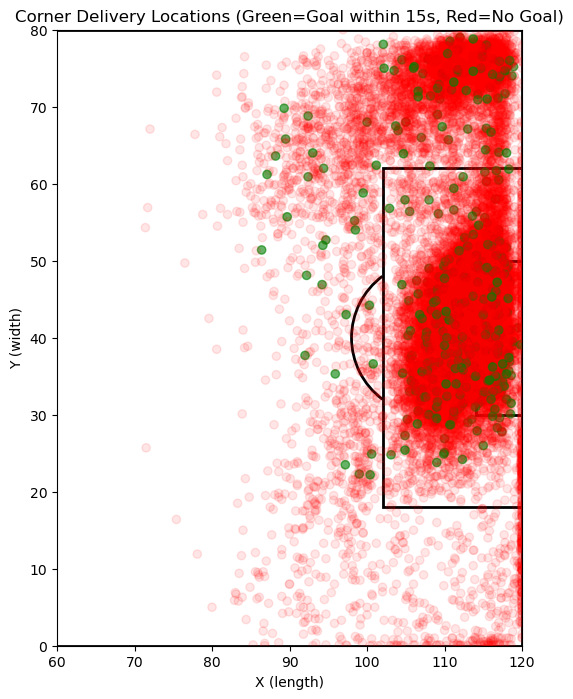

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc

fig, ax = plt.subplots(figsize=(6, 8))

ax.add_patch(Rectangle((0, 0), 120, 80, linewidth=2, edgecolor='black', facecolor='none'))
ax.add_patch(Rectangle((102, 18), 18, 44, linewidth=2, edgecolor='black', facecolor='none'))
ax.add_patch(Arc((108, 40), 20, 20, theta1=127, theta2=233, linewidth=2, edgecolor='black'))
ax.add_patch(Rectangle((114, 30), 6, 20, linewidth=2, edgecolor='black', facecolor='none'))

alphas = df_corners['success'].map({True: 0.6,
                                    False: 0.1})

colors = df_corners['success'].map({True: 'green', False: 'red'})

ax.scatter(df_corners['end_x'], df_corners['end_y'], 
           c=colors, alpha=alphas)

ax.set_xlim(60, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('Corner Delivery Locations (Green=Goal within 15s, Red=No Goal)')
plt.show()


This is difficult to visualize at the moment. Let’s divide the pitch into 5×5 unit areas to examine whether more specific locations, both inside and outside the box, have higher or lower corner success rates.

In [ ]:
x_edges = np.arange(90, 125, 5)
y_edges = np.arange(0, 85, 5)

df_corners['x_bin'] = pd.cut(df_corners['end_x'], bins=x_edges, labels=False, include_lowest=True)
df_corners['y_bin'] = pd.cut(df_corners['end_y'], bins=y_edges, labels=False, include_lowest=True)

zone_counts = df_corners.groupby('zone')['success'].agg(['count', 'sum'])
print(zone_counts.head())

            count  sum
zone                  
In Box      27215  868
Out of Box   6831  118


In [ ]:
print(df_corners[['end_x','x_bin','end_y','y_bin']].head(1000))


     end_x  x_bin  end_y  y_bin
0    110.5    4.0   29.4    5.0
1    117.0    5.0   39.3    7.0
2    113.7    4.0   35.4    7.0
3    111.4    4.0   37.4    7.0
4    109.1    3.0    3.9    0.0
..     ...    ...    ...    ...
995  110.8    4.0   35.9    7.0
996  109.8    3.0   42.8    8.0
997  107.1    3.0   71.7   14.0
998  117.0    5.0   49.0    9.0
999  117.0    5.0   58.0   11.0

[1000 rows x 4 columns]


/tmp/ipykernel_138331/4024208351.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = df_plot.groupby(['x_bin', 'y_bin']).agg(


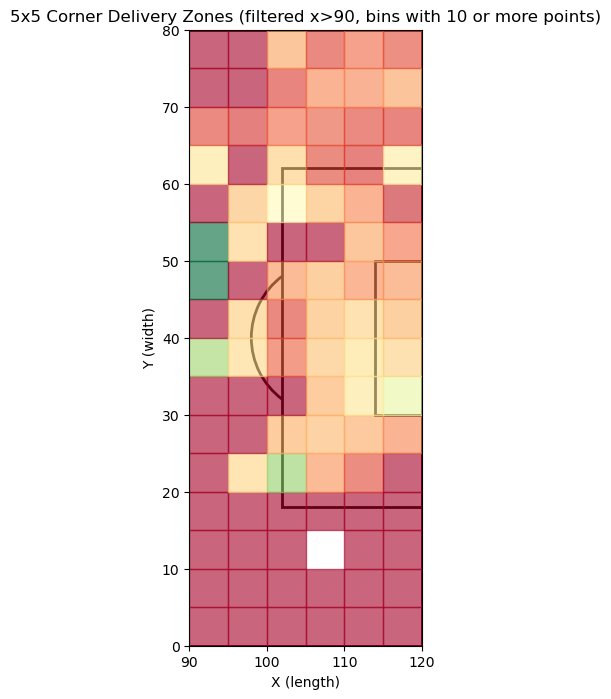

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
import numpy as np
from matplotlib.colors import Normalize

df_plot = df_corners[(df_corners['end_x'] > 90) & 
                     (~df_corners['end_x'].isna()) & 
                     (~df_corners['end_y'].isna())].copy()

x_bins = np.arange(90, 121, 5)
y_bins = np.arange(0, 81, 5)

df_plot['x_bin'] = pd.cut(df_plot['end_x'], bins=x_bins)
df_plot['y_bin'] = pd.cut(df_plot['end_y'], bins=y_bins)

bin_summary = df_plot.groupby(['x_bin', 'y_bin']).agg(
    count=('success', 'count'),
    success_rate=('success', 'mean')
).reset_index()

min_points = 10
bin_summary = bin_summary[bin_summary['count'] >= min_points]

fig, ax = plt.subplots(figsize=(3, 8))
ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))  # pitch outline
ax.add_patch(Rectangle((102,18),18,44,linewidth=2,edgecolor='black',facecolor='none'))  # penalty box
ax.add_patch(Rectangle((114,30),6,20,linewidth=2,edgecolor='black',facecolor='none'))  # six-yard box
ax.add_patch(Arc((108,40),20,20,theta1=127,theta2=233,linewidth=2,edgecolor='black'))  # penalty arc

vmin = 0
vmax = 0.1
norm = Normalize(vmin=vmin, vmax=vmax)

for _, row in bin_summary.iterrows():
    x0 = row['x_bin'].left
    y0 = row['y_bin'].left
    width = row['x_bin'].right - row['x_bin'].left
    height = row['y_bin'].right - row['y_bin'].left
    color = plt.cm.RdYlGn(norm(row['success_rate']))  # normalize to realistic range
    ax.add_patch(Rectangle((x0, y0), width, height, color=color, alpha=0.6))
    
ax.set_xlim(90, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('5x5 Corner Delivery Zones (filtered x>90, bins with 10 or more points)')
plt.show()


It is hard to get a grasp of what exactly this means. Maybe the boxes are too broad? Let's make the bins smaller, 2x2 next.

/tmp/ipykernel_138331/952181112.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = df_plot.groupby(['x_bin', 'y_bin']).agg(


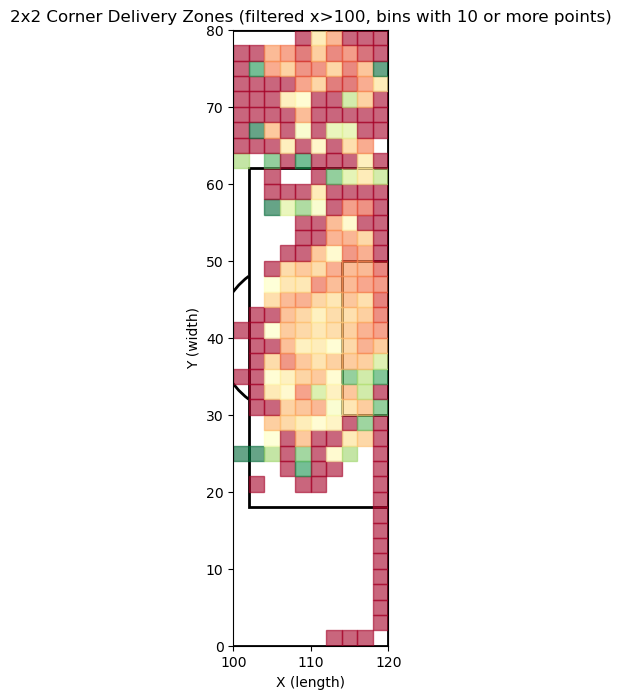

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
import numpy as np
from matplotlib.colors import Normalize

df_plot = df_corners[(df_corners['end_x'] > 100) & 
                     (~df_corners['end_x'].isna()) & 
                     (~df_corners['end_y'].isna())].copy()

x_bins = np.arange(100, 121, 2)
y_bins = np.arange(0, 81, 2)

df_plot['x_bin'] = pd.cut(df_plot['end_x'], bins=x_bins)
df_plot['y_bin'] = pd.cut(df_plot['end_y'], bins=y_bins)

bin_summary = df_plot.groupby(['x_bin', 'y_bin']).agg(
    count=('success', 'count'),
    success_rate=('success', 'mean')
).reset_index()

min_points = 10
bin_summary = bin_summary[bin_summary['count'] >= min_points]

fig, ax = plt.subplots(figsize=(2, 8))
ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))  # pitch outline
ax.add_patch(Rectangle((102,18),18,44,linewidth=2,edgecolor='black',facecolor='none'))  # penalty box
ax.add_patch(Rectangle((114,30),6,20,linewidth=2,edgecolor='black',facecolor='none'))  # six-yard box
ax.add_patch(Arc((108,40),20,20,theta1=127,theta2=233,linewidth=2,edgecolor='black'))  # penalty arc

vmin = 0
vmax = 0.1
norm = Normalize(vmin=vmin, vmax=vmax)

for _, row in bin_summary.iterrows():
    x0 = row['x_bin'].left
    y0 = row['y_bin'].left
    width = row['x_bin'].right - row['x_bin'].left
    height = row['y_bin'].right - row['y_bin'].left
    color = plt.cm.RdYlGn(norm(row['success_rate']))  # normalize to realistic range
    ax.add_patch(Rectangle((x0, y0), width, height, color=color, alpha=0.6))
    
ax.set_xlim(100, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('2x2 Corner Delivery Zones (filtered x>100, bins with 10 or more points)')
plt.show()


Now I feel like this is TOO specific, a lot of boxes don't have enough points, and some just vary by too much between each other. But deliveries near the middle of the 18 yard box seem to be quite efficient.

Let's find a middle ground for these plots!

/tmp/ipykernel_138331/100609225.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = df_plot.groupby(['x_bin', 'y_bin']).agg(


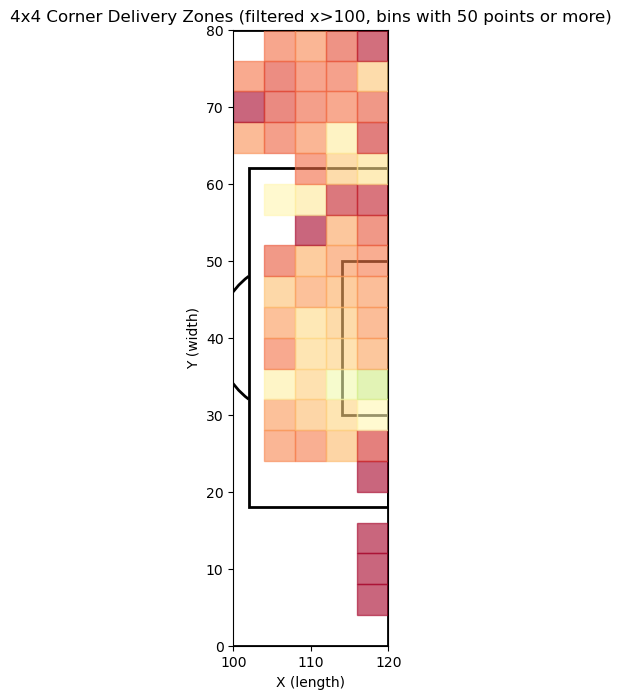

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
import numpy as np
from matplotlib.colors import Normalize

df_plot = df_corners[(df_corners['end_x'] > 90) & 
                     (~df_corners['end_x'].isna()) & 
                     (~df_corners['end_y'].isna())].copy()

x_bins = np.arange(100, 121, 4)
y_bins = np.arange(0, 81, 4)

df_plot['x_bin'] = pd.cut(df_plot['end_x'], bins=x_bins)
df_plot['y_bin'] = pd.cut(df_plot['end_y'], bins=y_bins)

bin_summary = df_plot.groupby(['x_bin', 'y_bin']).agg(
    count=('success', 'count'),
    success_rate=('success', 'mean')
).reset_index()

min_points = 50
bin_summary = bin_summary[bin_summary['count'] >= min_points]

fig, ax = plt.subplots(figsize=(2, 8))
ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))  # pitch outline
ax.add_patch(Rectangle((102,18),18,44,linewidth=2,edgecolor='black',facecolor='none'))  # penalty box
ax.add_patch(Rectangle((114,30),6,20,linewidth=2,edgecolor='black',facecolor='none'))  # six-yard box
ax.add_patch(Arc((108,40),20,20,theta1=127,theta2=233,linewidth=2,edgecolor='black'))  # penalty arc

vmin = 0
vmax = 0.1
norm = Normalize(vmin=vmin, vmax=vmax)

for _, row in bin_summary.iterrows():
    x0 = row['x_bin'].left
    y0 = row['y_bin'].left
    width = row['x_bin'].right - row['x_bin'].left
    height = row['y_bin'].right - row['y_bin'].left
    color = plt.cm.RdYlGn(norm(row['success_rate']))  # normalize to realistic range
    ax.add_patch(Rectangle((x0, y0), width, height, color=color, alpha=0.6))
    
ax.set_xlim(100, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('4x4 Corner Delivery Zones (filtered x>100, bins with 50 points or more)')
plt.show()


As we can see, deliveries into the box tend to be better than ones outside. In football, there are notably two main kinds of corner kick deliveries -- near post deliveries and far post deliveries. Let's delve deeper into this data to see what their impact along with both swing type and body part (head or other) on the success rates.

In [ ]:
def zone_type(row):
    if row['end_x'] > 102 and row['end_y'] < 40:  # near post
        return 'Near Post'
    elif row['end_x'] > 102 and row['end_y'] >= 40:  # far post
        return 'Far Post'
    else:
        return 'Other'

df_corners['zone_post'] = df_corners.apply(zone_type, axis=1)
df_corners['recipient_body_part'] = df_corners['recipient_body_part'].apply(
    lambda x: 'Head' if x=='Head' else 'Other'
)
df_corners['recipient_body_part']


0         Head
1        Other
2        Other
3         Head
4        Other
         ...  
34044    Other
34045    Other
34046    Other
34047    Other
34048     Head
Name: recipient_body_part, Length: 34046, dtype: object

In [ ]:
df_corners['recipient_body_part'] = df_corners['recipient_body_part'].apply(lambda x: 'Head' if x == 'Head' else 'Other')

group_stats = df_corners.groupby(
    ['zone_post', 'swing_type', 'recipient_body_part']
).agg(
    count=('success', 'size'),
    successes=('success', 'sum')
).reset_index()

group_stats['success_rate'] = group_stats['successes'] / group_stats['count']

group_stats = group_stats[group_stats['count'] >= 10]

group_stats = group_stats.sort_values(by='success_rate', ascending=False)
group_stats


,zone_post,swing_type,recipient_body_part,count,successes,success_rate
2,Far Post,outswinging,Head,2485,214,0.086117
0,Far Post,inswinging,Head,1378,115,0.083454
4,Near Post,inswinging,Head,1042,84,0.080614
6,Near Post,outswinging,Head,1897,139,0.073274
7,Near Post,outswinging,Other,4793,86,0.017943
11,Other,outswinging,Other,1135,20,0.017621
5,Near Post,inswinging,Other,2570,45,0.017510
9,Other,inswinging,Other,479,8,0.016701
1,Far Post,inswinging,Other,6083,95,0.015617
3,Far Post,outswinging,Other,12146,180,0.014820


I am skeptical about these results, as a success rate of 7-9% is extremely high. I want to try to pivot away from using contact, as I feel it is unreliable. It may be a data collection issue, but any potential solution that I haven't attempted exhaustively is just not feasible.

I am going to take a step back and use a different way of categorizing locations. I found a study for corner kicks in the irish league and they utilize a heuristic where the bins in the box are specific enough to be meaningful and not uniform boxes throughout. If I use this, I can classify corner kicks' delivery locations better and potentially be able to make a decisive conclusion also supported by statistical analysis for where it is best to deliver a ball into the box.

https://www.tandfonline.com/doi/full/10.1080/24748668.2019.1677329#d1e530

In [ ]:
# Edge is between (100 < X < 108, 30 < Y < 50
# FZ (Front Zone) is between (102 < X < 120, 50 < Y < 62)
# BZ (Back Zone) is between (102 < X < 120, 18 < Y < 30)
# GA1 is between (114 < X < 120, 44 < Y < 50)
# GA2 is between (114 < X < 120, 36 < Y < 44)
# GA3 is between (114 < X < 120, 30 < Y < 36)
# CA1 is between (108 < X < 114, 44 < Y < 50)
# CA2 is between (108 < X < 114, 36 < Y < 44)
# CA3 is between (108 < X < 114, 30 < Y < 36)


In [ ]:
def assign_corner_zone(x, y):
    if 100 < x < 108 and 30 < y < 50:
        return 'Edge'
    elif 102 < x < 120 and 50 < y < 62:
        return 'FZ'
    elif 102 < x < 120 and 18 < y < 30:
        return 'BZ'
    elif 114 < x < 120 and 44 < y < 50:
        return 'GA1'
    elif 114 < x < 120 and 36 < y < 44:
        return 'GA2'
    elif 114 < x < 120 and 30 < y < 36:
        return 'GA3'
    elif 108 < x < 114 and 44 < y < 50:
        return 'CA1'
    elif 108 < x < 114 and 36 < y < 44:
        return 'CA2'
    elif 108 < x < 114 and 30 < y < 36:
        return 'CA3'
    else:
        return 'Other'


In [ ]:
df_corners['zone'] = df_corners.apply(lambda row: assign_corner_zone(row['end_x'], row['end_y']), axis=1)


In [ ]:
zone_stats = df_corners.groupby('zone')['success'].agg(['sum', 'count'])
zone_stats['success_rate'] = zone_stats['sum'] / zone_stats['count']
print(zone_stats)


       sum  count  success_rate
zone                           
BZ      26    960      0.027083
CA1    104   3579      0.029058
CA2    239   6156      0.038824
CA3     71   2025      0.035062
Edge    41   1425      0.028772
FZ      53   2268      0.023369
GA1    104   3985      0.026098
GA2    138   4609      0.029941
GA3     54    871      0.061998
Other  156   8168      0.019099


Immediately it is clear that GA3, or a back post delivery inside of the six yard box is most effective. I want to plot these boxes like I did before.

In [ ]:
zone_coords = {
    'Edge': (100, 108, 30, 50),
    'FZ':   (102, 120, 50, 62),
    'BZ':   (102, 120, 18, 30),
    'GA1':  (114, 120, 44, 50),
    'GA2':  (114, 120, 36, 44),
    'GA3':  (114, 120, 30, 36),
    'CA1':  (108, 114, 44, 50),
    'CA2':  (108, 114, 36, 44),
    'CA3':  (108, 114, 30, 36),
    'Other': (100, 120, 0, 80)
}


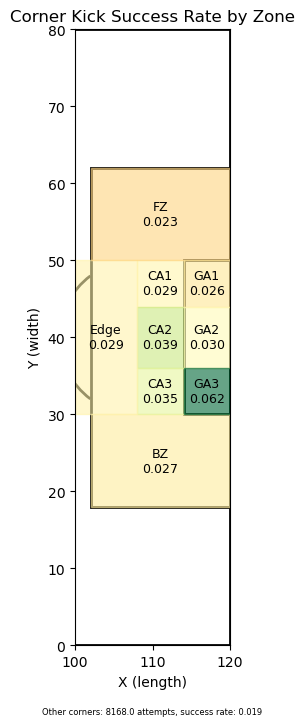

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize

plot_zones = zone_stats.drop(index='Other')

zone_coords = {
    'Edge': (100, 108, 30, 50),
    'FZ':   (102, 120, 50, 62),
    'BZ':   (102, 120, 18, 30),
    'GA1':  (114, 120, 44, 50),
    'GA2':  (114, 120, 36, 44),
    'GA3':  (114, 120, 30, 36),
    'CA1':  (108, 114, 44, 50),
    'CA2':  (108, 114, 36, 44),
    'CA3':  (108, 114, 30, 36)
}

vmin = 0
vmax = plot_zones['success_rate'].max()
norm = Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(2, 8))
ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))  # pitch outline
ax.add_patch(Rectangle((102,18),18,44,linewidth=2,edgecolor='black',facecolor='none'))  # penalty box
ax.add_patch(Rectangle((114,30),6,20,linewidth=2,edgecolor='black',facecolor='none'))  # six-yard box
ax.add_patch(Arc((108,40),20,20,theta1=127,theta2=233,linewidth=2,edgecolor='black'))  # penalty arc

for zone, row in plot_zones.iterrows():
    xmin, xmax, ymin, ymax = zone_coords[zone]
    color = plt.cm.RdYlGn(norm(row['success_rate']))
    ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color=color, alpha=0.6))
    ax.text((xmin+xmax)/2, (ymin+ymax)/2,
            f"{zone}\n{row['success_rate']:.3f}",
            ha='center', va='center', fontsize=9)

ax.set_xlim(100, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('Corner Kick Success Rate by Zone')

other = zone_stats.loc['Other']
ax.text(0.5, -0.1, f"Other corners: {other['count']} attempts, success rate: {other['success_rate']:.3f}",
        ha='center', va='top', transform=ax.transAxes, fontsize=6)

plt.show()


As we can see, it seems like maybe the deeper the delivery the better? I will explore that part later. Does swing type have an impact alongside the zones?

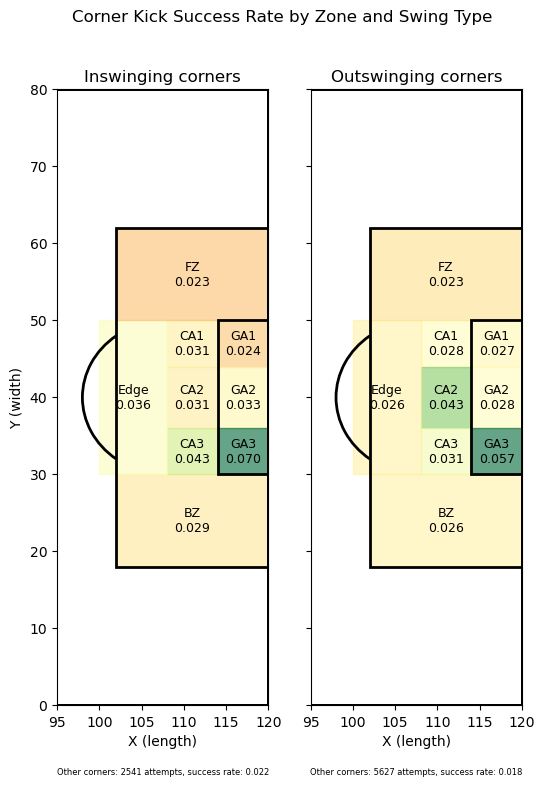

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize

zone_swing_stats = df_corners.groupby(['zone', 'swing_type'])['success'].agg(['sum','count']).reset_index()
zone_swing_stats['success_rate'] = zone_swing_stats['sum'] / zone_swing_stats['count']

zone_coords = {
    'Edge': (100, 108, 30, 50),
    'FZ':   (102, 120, 50, 62),
    'BZ':   (102, 120, 18, 30),
    'GA1':  (114, 120, 44, 50),
    'GA2':  (114, 120, 36, 44),
    'GA3':  (114, 120, 30, 36),
    'CA1':  (108, 114, 44, 50),
    'CA2':  (108, 114, 36, 44),
    'CA3':  (108, 114, 30, 36)
}

swing_types = ['inswinging', 'outswinging']

fig, axes = plt.subplots(1, 2, figsize=(6, 8), sharey=True)

for ax, swing in zip(axes, swing_types):
    stats = zone_swing_stats[zone_swing_stats['swing_type'] == swing]
    
    vmin = 0
    vmax = stats['success_rate'].max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))
    
    for _, row in stats.iterrows():
        zone = row['zone']
        if zone == 'Other':
            continue
            
        xmin, xmax, ymin, ymax = zone_coords[zone]
        color = plt.cm.RdYlGn(norm(row['success_rate']))
        ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color=color, alpha=0.6))
        ax.text((xmin+xmax)/2, (ymin+ymax)/2,
                f"{zone}\n{row['success_rate']:.3f}",
                ha='center', va='center', fontsize=9)
    
    ax.set_xlim(95, 120)
    ax.set_ylim(0, 80)
    ax.set_xlabel('X (length)')
    ax.set_title(f"{swing.capitalize()} corners")

    ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))  # pitch outline
    ax.add_patch(Rectangle((102,18),18,44,linewidth=2,edgecolor='black',facecolor='none'))  # penalty box
    ax.add_patch(Rectangle((114,30),6,20,linewidth=2,edgecolor='black',facecolor='none'))  # six-yard box
    ax.add_patch(Arc((108,40),20,20,theta1=127,theta2=233,linewidth=2,edgecolor='black'))  # penalty arc
    
    other = stats[stats['zone'] == 'Other']
    if not other.empty:
        other_row = other.iloc[0]
        ax.text(0.5, -0.1, f"Other corners: {other_row['count']} attempts, success rate: {other_row['success_rate']:.3f}",
                ha='center', va='top', transform=ax.transAxes, fontsize=6)

axes[0].set_ylabel('Y (width)')
plt.suptitle('Corner Kick Success Rate by Zone and Swing Type')
plt.show()


In [ ]:
zone_swing_stats = df_corners.groupby(['zone', 'swing_type'])['success'].agg(['sum', 'count']).reset_index()
zone_swing_stats['success_rate'] = zone_swing_stats['sum'] / zone_swing_stats['count']

zone_swing_stats = zone_swing_stats.sort_values(by='success_rate', ascending=False)

print(zone_swing_stats)


     zone   swing_type  sum  count  success_rate
16    GA3   inswinging   23    329      0.069909
17    GA3  outswinging   31    542      0.057196
6     CA3   inswinging   31    717      0.043236
5     CA2  outswinging  174   4041      0.043059
8    Edge   inswinging   15    421      0.035629
14    GA2   inswinging   58   1774      0.032694
2     CA1   inswinging   36   1157      0.031115
4     CA2   inswinging   65   2115      0.030733
7     CA3  outswinging   40   1308      0.030581
0      BZ   inswinging   10    339      0.029499
15    GA2  outswinging   80   2835      0.028219
3     CA1  outswinging   68   2422      0.028076
13    GA1  outswinging   68   2503      0.027167
9    Edge  outswinging   26   1004      0.025896
1      BZ  outswinging   16    621      0.025765
12    GA1   inswinging   36   1482      0.024291
10     FZ   inswinging   16    684      0.023392
11     FZ  outswinging   37   1584      0.023359
18  Other   inswinging   57   2541      0.022432
19  Other  outswingi

It appears that inswinging and outswinging GA3 deliveries are both the best kinds of deliveries, which is similar to what we found earlier in the 4x4 bin plot. Let's see if this is statistically significant.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

ga3_inswing = df_corners[(df_corners['zone'] == 'GA3') & (df_corners['swing_type'] == 'inswinging')]
success_ga3 = ga3_inswing['success'].sum()
n_ga3 = len(ga3_inswing)

other = df_corners[~((df_corners['zone'] == 'GA3') & (df_corners['swing_type'] == 'inswinging'))]
success_other = other['success'].sum()
n_other = len(other)

# Two-sample proportion z-test
count = [success_ga3, success_other]
nobs = [n_ga3, n_other]
stat, pval = proportions_ztest(count, nobs)
print(f"GA3 inswinging vs others: z={stat:.3f}, p={pval:.4f}")


GA3 inswinging vs others: z=4.451, p=0.0000


It appears that GA3 inswinging is a statistically significant improvement over the baseline 3.2% success rate observed in the dataset.

Logistic regression is a perfect way of looking at this data, as it is great for analyzing categorical binary data (success and failure in this case) from many different variables.

In [ ]:
df_corners['success_int'] = df_corners['success'].astype(int)

df_corners['zone'] = df_corners['zone'].astype('category')
df_corners['swing_type'] = df_corners['swing_type'].astype('category')

import statsmodels.formula.api as smf

model_zone = smf.logit('success_int ~ C(zone)', data=df_corners).fit()

model_zone_swing = smf.logit('success_int ~ C(zone) + C(swing_type)', data=df_corners).fit()


Optimization terminated successfully.
         Current function value: 0.129883
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.129878
         Iterations 8


In [ ]:
print(model_zone_swing.summary())


                           Logit Regression Results                           
Dep. Variable:            success_int   No. Observations:                34046
Model:                          Logit   Df Residuals:                    34035
Method:                           MLE   Df Model:                           10
Date:                Thu, 04 Dec 2025   Pseudo R-squ.:                0.009404
Time:                        10:30:40   Log-Likelihood:                -4421.8
converged:                       True   LL-Null:                       -4463.8
Covariance Type:            nonrobust   LLR p-value:                 8.376e-14
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -3.5572      0.204    -17.480      0.000      -3.956      -3.158
C(zone)[T.CA1]                   0.0736      0.222      0.331      0.741     

In [ ]:
model_interaction = smf.logit('success_int ~ C(zone) * C(swing_type)', data=df_corners).fit()
print(model_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.129691
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            success_int   No. Observations:                34046
Model:                          Logit   Df Residuals:                    34026
Method:                           MLE   Df Model:                           19
Date:                Thu, 04 Dec 2025   Pseudo R-squ.:                 0.01083
Time:                        10:30:40   Log-Likelihood:                -4415.4
converged:                       True   LL-Null:                       -4463.8
Covariance Type:            nonrobust   LLR p-value:                 2.093e-12
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                             

Using the p values, zone GA3 is the most statistically significant zone with a p value of 0.03, followed by CA3 at 0.195, but the evidence using this data conclusively proves GA3, or close to goal far post corner kicks are the best way to deliver them, with success rates varying between 5.7-7%, depending on the swing type.

Unfortunately, any other area other than GA3 is statistically insignificant. Additionally, swing_type is still insignificant in this model, similar to what we saw earlier on in the initial exploration.

Can we plot and try linear regression on the end_y variable? What about both end_y and end_x? Can we find the exact point based off this data, more granular than GA3?

/tmp/ipykernel_138331/3126264226.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y_success = df_corners.groupby('y_bin')['success_int'].mean()
/tmp/ipykernel_138331/3126264226.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_success = df_corners.groupby('x_bin')['success_int'].mean()


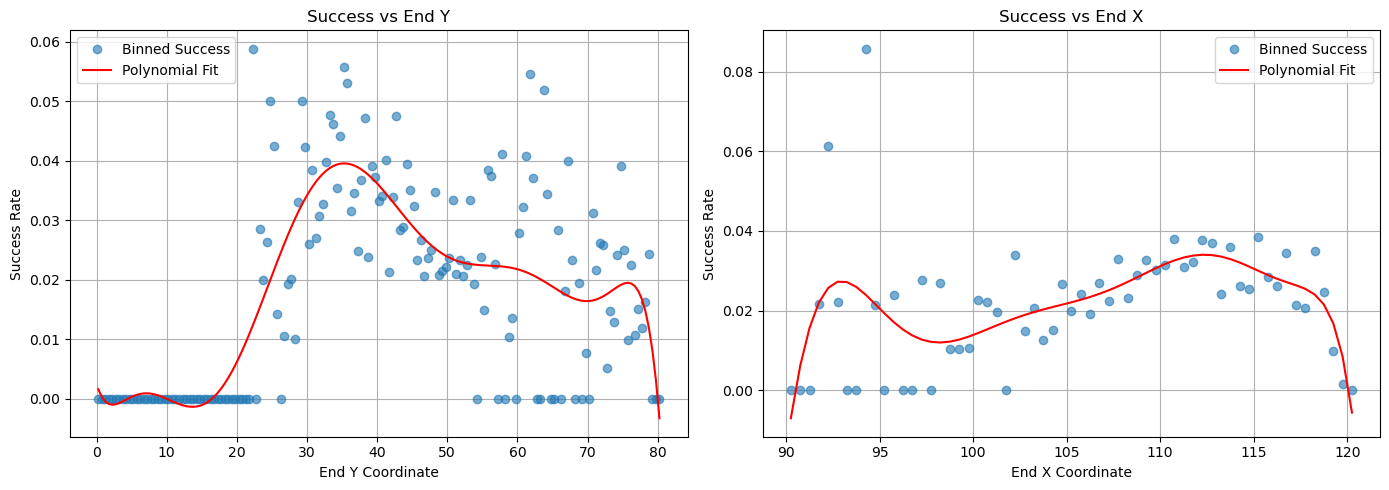

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_corners['success_int'] = df_corners['success'].astype(int)

y_bins = np.arange(0, 81, 0.5)
df_corners['y_bin'] = pd.cut(df_corners['end_y'], bins=y_bins)

y_success = df_corners.groupby('y_bin')['success_int'].mean()
y_centers = [interval.left + (interval.right-interval.left)/2 for interval in y_success.index]

y_poly = np.poly1d(np.polyfit(y_centers, y_success, deg=9))
y_smooth = y_poly(y_centers)

x_bins = np.arange(90, 121, 0.5)
df_corners['x_bin'] = pd.cut(df_corners['end_x'], bins=x_bins)

x_success = df_corners.groupby('x_bin')['success_int'].mean()
x_centers = [interval.left + (interval.right-interval.left)/2 for interval in x_success.index]

x_poly = np.poly1d(np.polyfit(x_centers, x_success, deg=9))
x_smooth = x_poly(x_centers)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# End Y
axes[0].plot(y_centers, y_success, 'o', alpha=0.6, label='Binned Success')
axes[0].plot(y_centers, y_smooth, '-', color='red', label='Polynomial Fit')
axes[0].set_xlabel('End Y Coordinate')
axes[0].set_ylabel('Success Rate')
axes[0].set_title('Success vs End Y')
axes[0].legend()
axes[0].grid(True)

# End X
axes[1].plot(x_centers, x_success, 'o', alpha=0.6, label='Binned Success')
axes[1].plot(x_centers, x_smooth, '-', color='red', label='Polynomial Fit')
axes[1].set_xlabel('End X Coordinate')
axes[1].set_ylabel('Success Rate')
axes[1].set_title('Success vs End X')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

y_fine = np.linspace(min(y_centers), max(y_centers), 500)
y_smooth_fine = y_poly(y_fine)
y_peak_idx = np.argmax(y_smooth_fine)
y_peak = y_fine[y_peak_idx]

x_fine = np.linspace(min(x_centers), max(x_centers), 500)
x_smooth_fine = x_poly(x_fine)
x_peak_idx = np.argmax(x_smooth_fine)
x_peak = x_fine[x_peak_idx]

print(f"{x_peak:.2f}, {y_peak:.2f}")


112.37, 35.36


/tmp/ipykernel_138331/238103027.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_stats = df_corners.groupby('zone')['success'].agg(['sum','count']).reset_index()


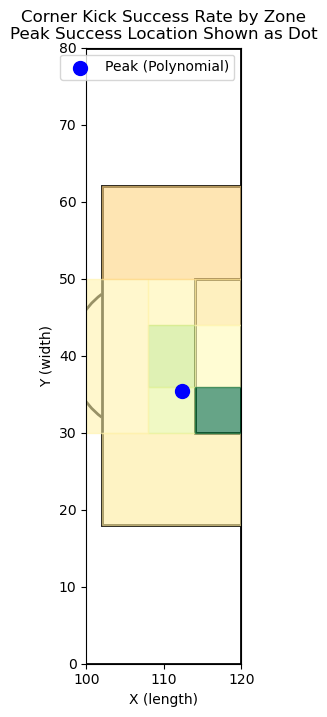

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc
from matplotlib.colors import Normalize

zone_stats = df_corners.groupby('zone')['success'].agg(['sum','count']).reset_index()
zone_stats['success_rate'] = zone_stats['sum'] / zone_stats['count']

zone_coords = {
    'Edge': (100, 108, 30, 50),
    'FZ':   (102, 120, 50, 62),
    'BZ':   (102, 120, 18, 30),
    'GA1':  (114, 120, 44, 50),
    'GA2':  (114, 120, 36, 44),
    'GA3':  (114, 120, 30, 36),
    'CA1':  (108, 114, 44, 50),
    'CA2':  (108, 114, 36, 44),
    'CA3':  (108, 114, 30, 36)
}

fig, ax = plt.subplots(figsize=(2, 8))

vmin = 0
vmax = zone_stats['success_rate'].max()
norm = Normalize(vmin=vmin, vmax=vmax)

ax.add_patch(Rectangle((0,0),120,80,linewidth=2,edgecolor='black',facecolor='none'))
ax.add_patch(Rectangle((102,18),18,44,linewidth=2,edgecolor='black',facecolor='none'))  # penalty box
ax.add_patch(Rectangle((114,30),6,20,linewidth=2,edgecolor='black',facecolor='none'))  # six-yard box
ax.add_patch(Arc((108,40),20,20,theta1=127,theta2=233,linewidth=2,edgecolor='black'))  # penalty arc

for _, row in zone_stats.iterrows():
    zone = row['zone']
    if zone == 'Other':
        continue
    xmin, xmax, ymin, ymax = zone_coords[zone]
    color = plt.cm.RdYlGn(norm(row['success_rate']))
    ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color=color, alpha=0.6))

ax.scatter(x_peak, y_peak, color='blue', s=100, zorder=10, label='Peak (Polynomial)')

ax.set_xlim(100, 120)
ax.set_ylim(0, 80)
ax.set_xlabel('X (length)')
ax.set_ylabel('Y (width)')
ax.set_title('Corner Kick Success Rate by Zone\nPeak Success Location Shown as Dot')
ax.legend()
plt.show()


The independent polynomial models for end_y and end_x identify this specific point as the optimal delivery. It lies near four zones that all show relatively high success rates, which aligns well with the observed data.

What about short passes? Are they a valuable alternative to crosses into the box? Let's explore.

Short delivery count: 4185
Short delivery success rate: 0.019


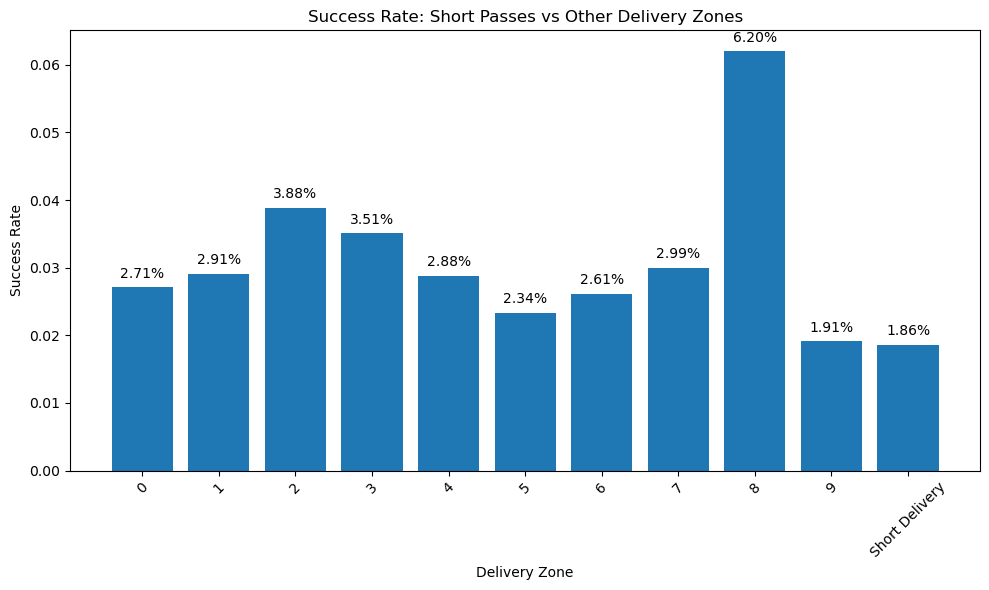

In [ ]:
short_passes = df_corners[
    (df_corners['end_x'] > 105) & (df_corners['end_x'] < 120) &
    (df_corners['end_y'] > 65) & (df_corners['end_y'] < 80)
]

short_success_rate = short_passes['success'].mean() if len(short_passes) > 0 else 0

print(f"Short delivery count: {len(short_passes)}")
print(f"Short delivery success rate: {short_success_rate:.3f}")

short_row = zone_stats.iloc[0] * 0
short_row['success'] = short_passes['success'].sum()
short_row['count'] = len(short_passes)
short_row['success_rate'] = short_success_rate

zone_stats.loc['Short Delivery'] = short_row

compare_series = zone_stats['success_rate']
compare_series.index = compare_series.index.astype(str)

plt.figure(figsize=(10, 6))
bars = plt.bar(compare_series.index, compare_series.values)

plt.xlabel("Delivery Zone")
plt.ylabel("Success Rate")
plt.title("Success Rate: Short Passes vs Other Delivery Zones")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.001,
             f"{height:.2%}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


This shows that in every single scenario for this dataset, at least, short deliveries are subpar.